In [75]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [76]:
data_path = r'C:\hotel_booking\Data\Raw_Data\hotel_bookings_updated_2024.csv'
df = pd.read_csv(data_path)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,16:40.9,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,56:21.5,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,46:25.7,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,07:10.1,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,27:32.5,Lucknow


In [65]:
for col in df.columns:
    print(f"{col}:-> {df[col].dtype}")

hotel:-> object
is_canceled:-> int64
lead_time:-> int64
arrival_date_year:-> int64
arrival_date_month:-> object
arrival_date_week_number:-> int64
arrival_date_day_of_month:-> int64
stays_in_weekend_nights:-> int64
stays_in_week_nights:-> int64
adults:-> int64
children:-> float64
babies:-> int64
meal:-> object
country:-> object
market_segment:-> object
distribution_channel:-> object
is_repeated_guest:-> int64
previous_cancellations:-> int64
previous_bookings_not_canceled:-> int64
reserved_room_type:-> object
assigned_room_type:-> object
booking_changes:-> int64
deposit_type:-> object
agent:-> float64
company:-> float64
days_in_waiting_list:-> int64
customer_type:-> object
adr:-> float64
required_car_parking_spaces:-> int64
total_of_special_requests:-> int64
reservation_status:-> object
reservation_status_date:-> object
city:-> object


In [66]:
from pandas.api.types import is_numeric_dtype

for col in df.columns:
    if not is_numeric_dtype(df[col]):
        print(f"{col} -> {df[col].dtype}")

hotel -> object
arrival_date_month -> object
meal -> object
country -> object
market_segment -> object
distribution_channel -> object
reserved_room_type -> object
assigned_room_type -> object
deposit_type -> object
customer_type -> object
reservation_status -> object
reservation_status_date -> object
city -> object


In [74]:
df['distribution_channel'].value_counts()

distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

# Our target is is_canceled, let's explore it now

In [4]:
df['is_canceled'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 119390 entries, 0 to 119389
Series name: is_canceled
Non-Null Count   Dtype
--------------   -----
119390 non-null  int64
dtypes: int64(1)
memory usage: 932.9 KB


In [5]:
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [6]:
import matplotlib.pylab as plt

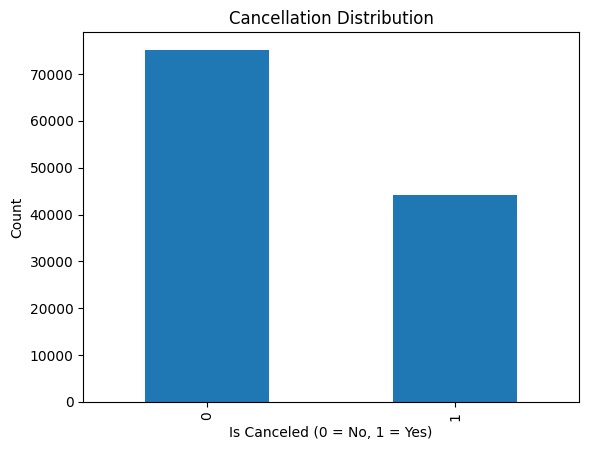

In [7]:
plt.Figure(figsize=(8, 8))

df['is_canceled'].value_counts().plot(kind='bar')

plt.title('Cancellation Distribution')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.show()

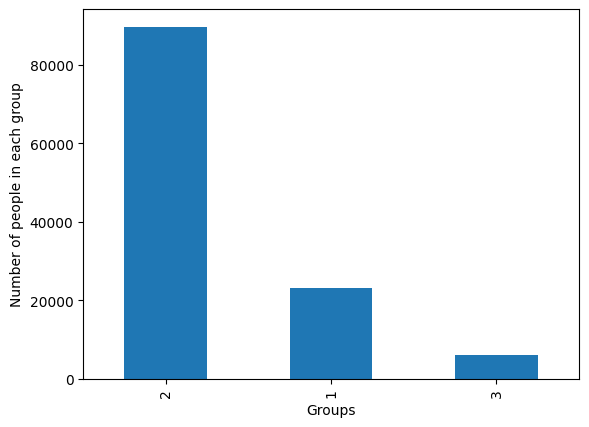

In [8]:
plt.Figure(figsize=(8, 8))

df['adults'].value_counts()[:3].plot(kind='bar')
plt.ylabel('Number of people in each group')
plt.xlabel('Groups')
plt.show()

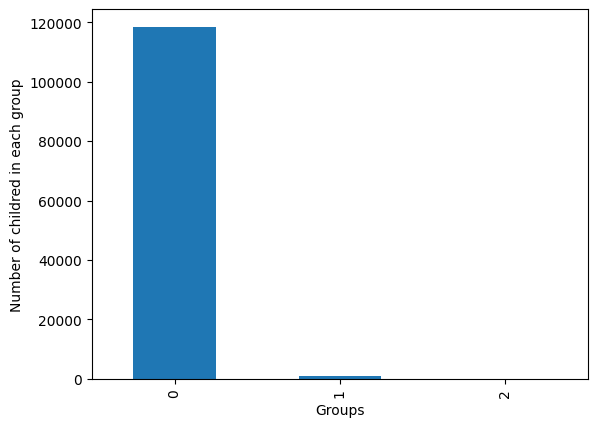

In [9]:
plt.Figure(figsize=(8, 8))

df['babies'].value_counts()[:3].plot(kind='bar')
plt.ylabel('Number of childred in each group')
plt.xlabel('Groups')
plt.show()

In [48]:
city_groups = df.groupby('city')['arrival_date_year'].sum()
city_groups

city
Ahmedabad     16248672
Bangalore     15983528
Bhopal        16402496
Chandigarh    16147472
Chennai       16040200
Delhi         16147472
Goa           16137352
Hyderabad     16153544
Indore        15841848
Jaipur        16268912
Kochi         15967336
Kolkata       16143424
Lucknow       15926856
Mumbai        16060440
Pune          16175808
Name: arrival_date_year, dtype: int64

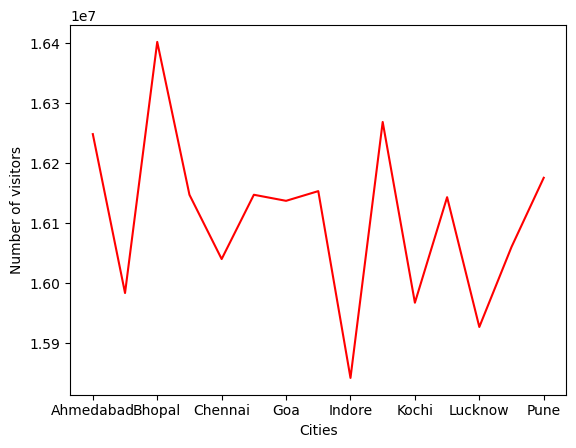

In [49]:
plt.Figure(figsize=(10, 16))
city_groups.plot(kind='line', color = 'red')
plt.ylabel('Number of visitors')
plt.xlabel('Cities')
plt.show()

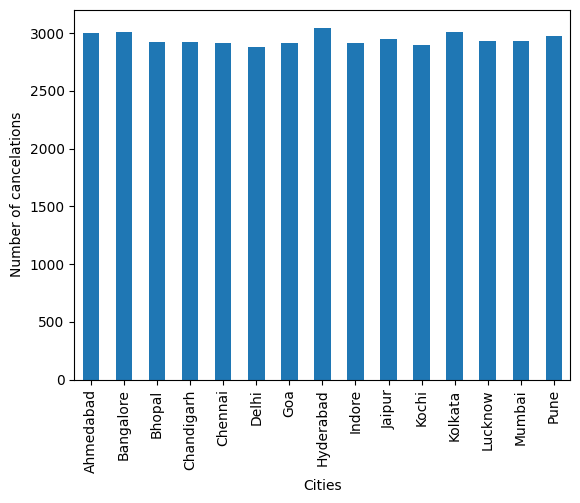

In [ ]:
city_groups = df.groupby('city')['is_canceled'].sum()
city_groups
plt.Figure(figsize=(10, 16))
city_groups.plot(kind='bar')
plt.ylabel('Number of cancelations')
plt.xlabel('Cities')
plt.show()

In [55]:
city_prev_cancel = df.groupby('city')['previous_cancellations'].sum()
city_prev_cancel

city
Ahmedabad     774
Bangalore     641
Bhopal        666
Chandigarh    663
Chennai       626
Delhi         654
Goa           775
Hyderabad     672
Indore        693
Jaipur        644
Kochi         700
Kolkata       797
Lucknow       634
Mumbai        707
Pune          755
Name: previous_cancellations, dtype: int64

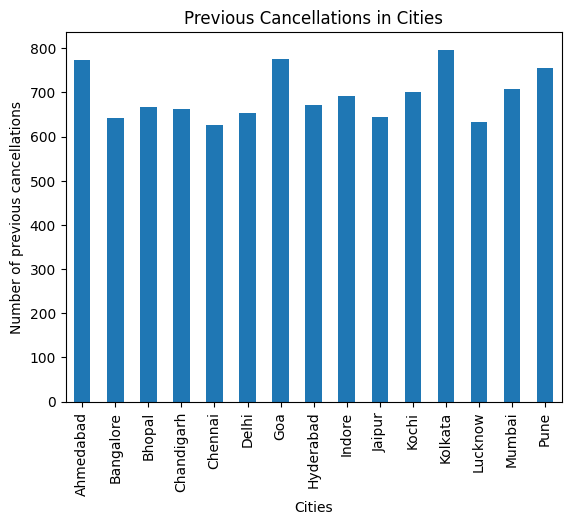

In [59]:
plt.Figure(figsize=(12, 12))

city_prev_cancel.plot(kind='bar')
plt.title('Previous Cancellations in Cities')
plt.ylabel('Number of previous cancellations')
plt.xlabel('Cities')
plt.show()

In [84]:
data = r'C:\hotel_booking\Data\Raw_Data\hotel_bookings_updated_2024.csv'
from sklearn.model_selection import train_test_split
df = pd.read_csv(data)
X = df.drop(columns='is_canceled')
y = df['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [85]:
import os
def imputation(X_train, X_test):
        
        X_train = X_train.copy()
        X_test = X_test.copy()
        try:
            fill_values = {}
            for col in X_train.columns:

                if X_train[col].dtype == 'object':
                    fill_values[col] = X_train[col].mode()[0]
                    X_train[col] = X_train[col].fillna(fill_values[col])
                else:
                    fill_values[col] = X_train[col].mean()
                    X_train[col] = X_train[col].fillna(fill_values[col])

            for col, value in fill_values.items():
                X_test[col] = X_test[col].fillna(value)

            # data_path = r'C:\hotel_booking\Data\Prep_Data\basic_prep'

            # os.makedirs(data_path, exist_ok=True)
            # out_path = os.path.join(data_path, 'X_train_imputed.csv')
            # X_train.to_csv(out_path, index = False)
            # ### X_Test saving
            # out_path = os.path.join(data_path, 'X_test_imputed.csv')
            # X_test.to_csv(out_path, index = False)
            # # logging.info(f'Imputed data is saved at {data_path}')
            return X_test, X_train
        except Exception as e:
            # logging.error(f'Error while doing imputation')
            raise

In [86]:
X_test_imp, X_train_imp = imputation(X_train=X_train, X_test=X_test)

In [87]:
X_test_imp.isnull().sum()

hotel                             0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [88]:
X_train_imp.isnull().sum()

hotel                             0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [89]:
X_train.isnull().sum()

hotel                                 0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             374
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             13061
company                           90092
days_in_waiting_list                  0


In [90]:
X_test.isnull().sum()

hotel                                 0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              0
babies                                0
meal                                  0
country                             114
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                              3279
company                           22501
days_in_waiting_list                  0
